In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/WELFake_Dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nHead:")
display(df.head())

print("\nInfo:")
df.info()

Shape: (72134, 4)

Columns:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

Head:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


---
## Osnovni pregled skupa podataka

Nakon učitavanja skupa podataka izvršen je inicijalni pregled strukture.

### Dimenzije skupa
Skup sadrži:

- **72,134 slogova (redova)**
- **4 atributa (kolone)**

### Atributi
Dataset sadrži sledeće kolone:

1. **Unnamed: 0** – indeks
2. **title** – naslov vesti
3. **text** – sadržaj vesti
4. **label** – ciljna promenljiva  
   - `0` → *fake news*  
   - `1` → *real news*

### Tipovi podataka

- `Unnamed: 0` → numerički (`int64`)
- `title` → tekstualni (`object`)
- `text` → tekstualni (`object`)
- `label` → numerički (`int64`)

### Nedostajuće vrednosti

Uočene su nedostajuće vrednosti:

- **title:** 558 nedostajućih vrednosti
- **text:** 39 nedostajućih vrednosti

Ova pojava je očekivana kod realnih tekstualnih datasetova i zahtevaće adekvatno preprocesiranje.

---

In [5]:
print("Label distribution:\n")
print(df['label'].value_counts())

print("\nLabel distribution (%):\n")
print(df['label'].value_counts(normalize=True) * 100)

Label distribution:

label
1    37106
0    35028
Name: count, dtype: int64

Label distribution (%):

label
1    51.440375
0    48.559625
Name: proportion, dtype: float64


---
## Distribucija ciljnih klasa

Analizom atributa `label` utvrđena je raspodela instanci po klasama:

- Klasa `1` (real news): 37,106 slogova
- Klasa `0` (fake news): 35,028 slogova

Procentualna raspodela:

- Real news: 51.44%
- Fake news: 48.56%

Zaključak:

Dataset je gotovo balansiran, što predstavlja povoljnu karakteristiku za primenu klasifikacionih algoritama, jer modeli neće biti pristrasni ka dominantnoj klasi. Ovakva raspodela omogućava realnije poređenje performansi različitih modela.

---

In [6]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [7]:
print("Empty strings in title:")
print((df['title'] == "").sum())

print("\nEmpty strings in text:")
print((df['text'] == "").sum())

Empty strings in title:
0

Empty strings in text:
0


In [8]:
df['text_length'] = df['text'].fillna("").apply(len)

print(df['text_length'].describe())

count     72134.000000
mean       3268.387834
std        3732.877545
min           0.000000
25%        1377.000000
50%        2424.000000
75%        4059.000000
max      142961.000000
Name: text_length, dtype: float64


In [9]:
df['word_count'] = df['text'].fillna("").apply(lambda x: len(x.split()))

print(df['word_count'].describe())

count    72134.000000
mean       540.550933
std        625.399748
min          0.000000
25%        227.000000
50%        398.000000
75%        667.000000
max      24234.000000
Name: word_count, dtype: float64


---
## Analiza nedostajućih vrednosti i osnovnih karakteristika teksta

### Nedostajuće vrednosti

Analizom nedostajućih vrednosti po kolonama dobijeni su sledeći rezultati:

- `Unnamed: 0`: 0 nedostajućih vrednosti
- `title`: 558 nedostajućih vrednosti
- `text`: 39 nedostajućih vrednosti
- `label`: 0 nedostajućih vrednosti

Zaključak:

Prisustvo nedostajućih vrednosti je ograničeno na tekstualne atribute (`title` i `text`) i čini mali procenat ukupnog skupa. Ovakva pojava je tipična za realne datasetove i zahtevaće adekvatno preprocesiranje (popunjavanje ili uklanjanje instanci).

---

### Dužina tekstualnog sadržaja

Statistika atributa `text_length` (broj karaktera):

- Minimum: 0
- 25% kvantil: 1377
- Medijana: 2424
- 75% kvantil: 4059
- Maksimum: 142,961
- Prosečna vrednost: 3268

Zaključak:

Većina tekstova ima nekoliko hiljada karaktera, ali postoje ekstremno dugi tekstovi (outliers). Ova heterogenost može uticati na performanse modela i vreme obrade.

---

### Broj reči u tekstu

Statistika atributa `word_count`:

- Minimum: 0
- 25% kvantil: 227
- Medijana: 398
- 75% kvantil: 667
- Maksimum: 24,234
- Prosečna vrednost: 540

Zaključak:

Distribucija broja reči potvrđuje veliku varijabilnost u veličini dokumenata. Postojanje instanci sa nulom reči ukazuje na prazne tekstove koji će zahtevati dodatnu obradu.

---

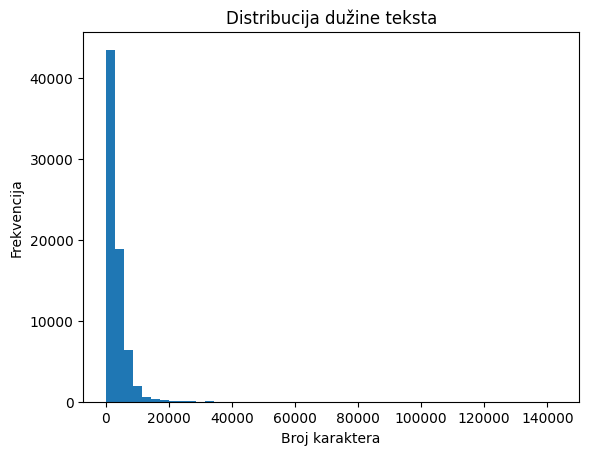

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['text_length'], bins=50)
plt.title("Distribucija dužine teksta")
plt.xlabel("Broj karaktera")
plt.ylabel("Frekvencija")
plt.show()

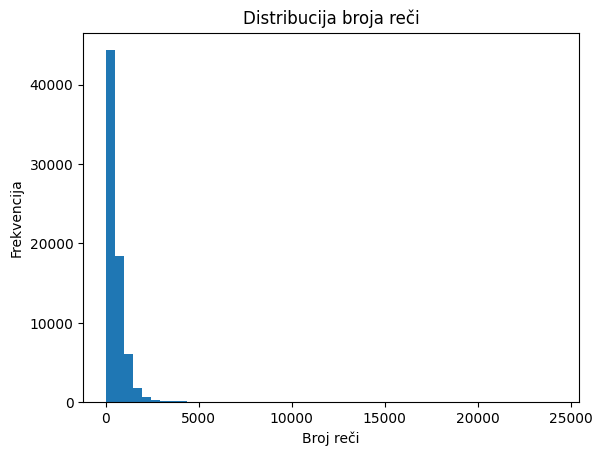

In [11]:
plt.figure()
plt.hist(df['word_count'], bins=50)
plt.title("Distribucija broja reči")
plt.xlabel("Broj reči")
plt.ylabel("Frekvencija")
plt.show()

<Figure size 640x480 with 0 Axes>

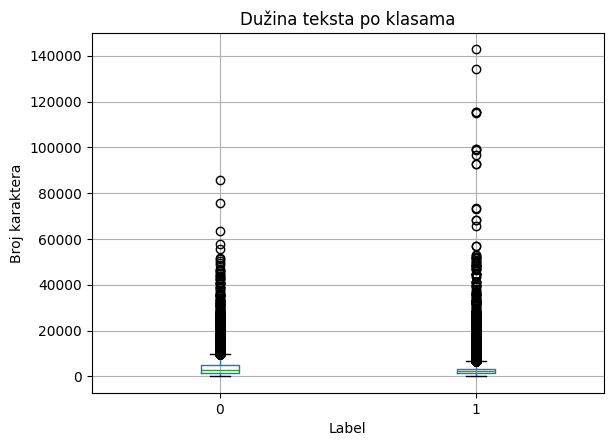

In [12]:
plt.figure()
df.boxplot(column='text_length', by='label')
plt.title("Dužina teksta po klasama")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Broj karaktera")
plt.show()

---

## Vizuelna analiza tekstualnih atributa

### Distribucija dužine teksta

Histogram atributa `text_length` pokazuje izrazito asimetričnu (right-skewed) distribuciju. Većina instanci ima relativno kratke do srednje duge tekstove, dok je prisutan manji broj ekstremno dugih tekstova.

Zaključak:

Distribucija ukazuje na postojanje outlier-a, što je očekivano kod tekstualnih datasetova. Ekstremno dugi tekstovi mogu uticati na vreme obrade i performanse modela, ali ne moraju nužno biti uklonjeni jer nose potencijalno korisne informacije.

---

### Distribucija broja reči

Histogram atributa `word_count` prati sličan obrazac kao i dužina teksta, dominantan broj dokumenata ima nekoliko stotina reči, uz prisustvo manjeg broja vrlo dugih tekstova.

Zaključak:

Varijabilnost u broju reči potvrđuje heterogenost dataset-a, što može uticati na stabilnost i generalizaciju modela.

---

### Dužina teksta po klasama

Boxplot atributa `text_length` po klasama (`label`) pokazuje da obe klase imaju slične raspodele, ali sa primetnim outlier-ima u obe grupe.

Zaključak:

Ne postoji značajna razlika u tipičnoj dužini teksta između fake i real vesti. Ovo sugeriše da sama dužina teksta verovatno neće biti dominantan diskriminativni faktor u klasifikaciji, te je neophodno koristiti sadržajne (semantičke) osobine teksta.

---

In [13]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,title,text,label,text_length,word_count
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,5049,871
1,NaN,Did they post their votes for Hillary already?,1,46,8
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,216,34
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,8010,1321
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,1916,329


In [14]:
df['title'] = df['title'].fillna("")
df['text'] = df['text'].fillna("")

df = df[~((df['title'] == "") & (df['text'] == ""))]

print("New shape:", df.shape)

New shape: (72134, 5)


In [15]:
df['content'] = df['title'] + " " + df['text']
df[['title', 'text', 'content']].head()

,title,text,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",SATAN 2: Russia unvelis an image of its terrif...


In [16]:
df['content_length'] = df['content'].apply(len)
print(df['content_length'].describe())

count     72134.000000
mean       3345.932154
std        3732.895573
min           2.000000
25%        1457.000000
50%        2500.000000
75%        4138.750000
max      143035.000000
Name: content_length, dtype: float64


---

## Preprocesiranje podataka

### Uklanjanje nepotrebnih atributa

Kolona `Unnamed: 0`, koja predstavlja indeks iz originalnog CSV fajla, uklonjena je iz daljeg razmatranja jer ne nosi informativnu vrednost za analizu.

---

### Obrada nedostajućih vrednosti

U kolonama `title` i `text` uočene su nedostajuće vrednosti. Primenjena je sledeća strategija:

- Nedostajuće vrednosti zamenjene su praznim stringom
- Redovi kod kojih su i `title` i `text` prazni bili bi uklonjeni

Nakon obrade, broj instanci ostao je nepromenjen, što ukazuje da dataset ne sadrži slogove bez tekstualnog sadržaja.

---

### Kreiranje kombinovanog atributa

Radi poboljšanja reprezentacije tekstualnih podataka kreiran je novi atribut:

content = title + text

Ovakav pristup omogućava objedinjavanje informacija iz naslova i glavnog teksta vesti, čime se povećava količina semantičkog signala dostupnog modelima.

---

### Karakteristike kombinovanog atributa

Statistika atributa `content_length` pokazuje:

- Medijana: 2500 karaktera
- Prosečna vrednost: 3346 karaktera
- Maksimum: 143035 karaktera

Zaključak:

Kombinovani atribut zadržava heterogenost originalnog tekstualnog sadržaja, uz prisustvo ekstremno dugih instanci koje predstavljaju potencijalne outlier-e.

---

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)          # uklanjanje viška whitespace
    text = re.sub(r'http\S+', '', text)       # uklanjanje URL
    text = re.sub(r'[^a-z\s]', '', text)      # uklanjanje specijalnih znakova
    return text.strip()

df['content_clean'] = df['content'].apply(clean_text)

df[['content', 'content_clean']].head()

,content,content_clean
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obamas attorney general says most...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story of christ...
4,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis an image of its terrifyi...


In [18]:
df['clean_length'] = df['content_clean'].apply(len)
print(df['clean_length'].describe())

count     72134.000000
mean       3206.682203
std        3550.499698
min           0.000000
25%        1385.000000
50%        2401.000000
75%        3973.000000
max      128520.000000
Name: clean_length, dtype: float64


In [19]:
df['clean_word_count'] = df['content_clean'].apply(lambda x: len(x.split()))
print(df['clean_word_count'].describe())

count    72134.000000
mean       541.282807
std        610.007358
min          0.000000
25%        232.000000
50%        403.000000
75%        667.000000
max      23833.000000
Name: clean_word_count, dtype: float64


---

## Normalizacija tekstualnog sadržaja

Radi pripreme podataka za primenu algoritama istraživanja podataka izvršena je osnovna normalizacija tekstualnog atributa `content`.

Primenjene transformacije:

- Konverzija u mala slova
- Uklanjanje URL-ova
- Uklanjanje specijalnih znakova i interpunkcije
- Uklanjanje viška razmaka

---

### Promene u dužini teksta

Statistika atributa `clean_length` pokazuje:

- Prosečna vrednost: 3206 karaktera
- Medijana: 2401 karakter
- Maksimum: 128520 karaktera

Zaključak:

Uočeno je smanjenje prosečne dužine teksta u odnosu na originalni atribut. Razlog tome je uklanjanje interpunkcije, specijalnih znakova i URL-ova.

---

### Promene u broju reči

Statistika atributa `clean_word_count` pokazuje:

- Prosečna vrednost: 541 reč
- Medijana: 403 reči
- Maksimum: 23833 reči

Zaključak:

Distribucija broja reči ostaje slična originalnoj, što potvrđuje da normalizacija nije dovela do gubitka značajne količine sadržaja, već do standardizacije zapisa.

---

### Opšti zaključak

Normalizacija teksta omogućava stabilniju reprezentaciju podataka i smanjuje šum koji bi mogao negativno uticati na performanse modela.

---

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df['content_clean'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (72134, 5000)


In [21]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

print("Explained variance (2D):", svd.explained_variance_ratio_.sum())

Explained variance (2D): 0.017452448983242008


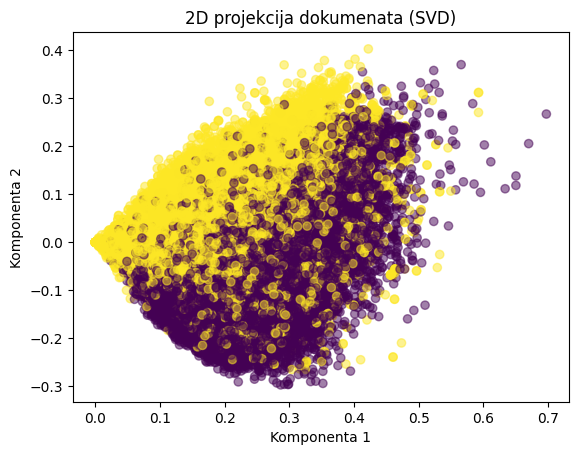

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['label'], alpha=0.5)
plt.title("2D projekcija dokumenata (SVD)")
plt.xlabel("Komponenta 1")
plt.ylabel("Komponenta 2")
plt.show()

## 2D projekcija dokumenata

Radi vizuelne analize tekstualnih podataka izvršena je TF-IDF vektorizacija sa 5000 atributa, nakon čega je primenjena redukcija dimenzionalnosti korišćenjem metode TruncatedSVD.

Dimenzije matrice nakon TF-IDF transformacije:

72134 × 5000

Ukupna objašnjena varijansa prve dve SVD komponente:

≈ 1.75%

---

### Vizuelni uvid

2D scatter projekcija pokazuje značajno preklapanje instanci obe klase (`fake` i `real`). Ne uočava se jasno razdvajanje klasa u dvodimenzionalnom prostoru.

---

### Zaključak

Relativno mala objašnjena varijansa ukazuje da dve komponente nisu dovoljne da verno predstave kompleksnu strukturu visokodimenzionalnog TF-IDF prostora.

Preklapanje klasa sugeriše da problem klasifikacije nije trivijalan i da će biti neophodna primena složenijih modela koji koriste punu dimenzionalnost podataka.

In [23]:
svd_3d = TruncatedSVD(n_components=3, random_state=42)
X_3d = svd_3d.fit_transform(X_tfidf)

print("Explained variance (3D):", svd_3d.explained_variance_ratio_.sum())

Explained variance (3D): 0.025743080795130012


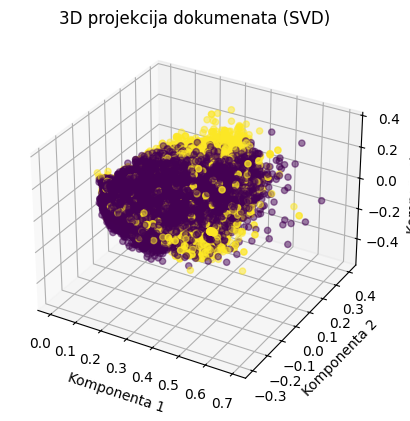

In [24]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=df['label'],
    alpha=0.5
)

ax.set_title("3D projekcija dokumenata (SVD)")
ax.set_xlabel("Komponenta 1")
ax.set_ylabel("Komponenta 2")
ax.set_zlabel("Komponenta 3")

plt.show()

## 3D projekcija dokumenata

Nakon TF-IDF reprezentacije tekstualnih podataka primenjena je redukcija dimenzionalnosti na tri komponente korišćenjem metode TruncatedSVD.

Ukupna objašnjena varijansa prve tri komponente:

≈ 2.57%

---

### Vizuelni uvid

3D projekcija pokazuje sličan obrazac kao i 2D projekcija. Instance obe klase (`fake` i `real`) ostaju značajno preklopljene, bez jasnog razdvajanja.

---

### Zaključak

Povećanje broja komponenti dovodi do blagog rasta objašnjene varijanse, ali i dalje predstavlja mali deo ukupne varijabilnosti podataka.

Rezultati potvrđuju da je struktura tekstualnog prostora visoko kompleksna i da se razlike između klasa ne mogu jasno sagledati u niskodimenzionalnoj projekciji.

Ovakav nalaz ukazuje na potrebu primene algoritama koji koriste punu dimenzionalnost podataka.

---

## Završni zaključci eksplorativne analize

Eksplorativna analiza pokazala je sledeće karakteristike dataset-a:

- Dataset je gotovo balansiran po klasama
- Prisutan je mali procenat nedostajućih vrednosti
- Tekstualni atributi pokazuju izrazitu varijabilnost dužine
- Distribucije su asimetrične sa prisustvom outlier-a
- 2D i 3D projekcije ne pokazuju jasno razdvajanje klasa

Zaključak:

Dataset predstavlja realan i kompleksan problem klasifikacije tekstualnih podataka. Jednostavne vizuelne projekcije nisu dovoljne za separaciju klasa, te će dalja analiza biti usmerena na primenu algoritama istraživanja podataka.

Sledeći korak predstavlja izgradnju i evaluaciju klasifikacionih modela.

In [26]:
df.to_csv("../data/processed/welfake_preprocessed.csv", index=False)